In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Matplotlib is building the font cache; this may take a moment.


### SciPy

SciPy provides a large number of functions that are useful for different types of scientific and engineering applications.  Many SciPy functions operate on numpy arrays.  For this course, we will primarily be using the **SciPy.Stats** sub-module. SciPy.Stats calculates density and mass functions, cumulative distribution functions, and quantile functions for many probability distributions.  We will use these functions in the second and third courses of this series when we do more formal statistical analysis.  If you are not familiar with probability distributions you can skip this section.

As a starting example, suppose we want to evaluate the cumulative distribution function (CDF) of the standard normal distribution at zero.  Since zero is the median of the standard normal distribution, the resulting cumulative probability should be 1/2.

In [4]:
print(stats.norm.cdf(0))

0.5


In [5]:
# The median of a standard Student's t distribution with 10 degrees of freedom
print(stats.t(10).ppf(0.5))

# The 97.5 percentile of a standard Student's t distribution with 5 degrees of freedom
print(stats.t(5).ppf(0.975))

# The probability that a standard normal value is less than or equal to 3
print(stats.expon.cdf(3))

# The height of the standard normal density function at 1
print(stats.norm.pdf(1))

# The probability of getting exactly 3 heads in 10 flips of a fair coin
print(stats.binom(10, 0.5).pmf(3))

# The probability of getting 3 or fewer heads in 10 flips of a fair coin
print(stats.binom(10, 0.5).cdf(3))

0.0
2.570581835636315
0.950212931632136
0.24197072451914337
0.11718749999999999
0.171875


### Matplotlib

#### Sine Wave

In [10]:
x=np.arange(0,3*np.pi,0.1) # start->stop->step
y=np.sin(x)


In [13]:
x[:5]

array([0. , 0.1, 0.2, 0.3, 0.4])

In [14]:
y[:5]

array([0.        , 0.09983342, 0.19866933, 0.29552021, 0.38941834])

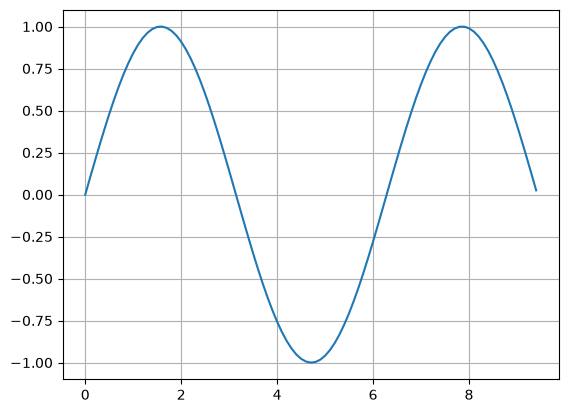

In [16]:
# plot the point using matplolib
plt.grid(True)
plt.plot(x,y)

Next we make a slightly fancier version of the sine wave with a grid,axis labels, and colored broken plotting lines

Text(0.5, 0, 'X')

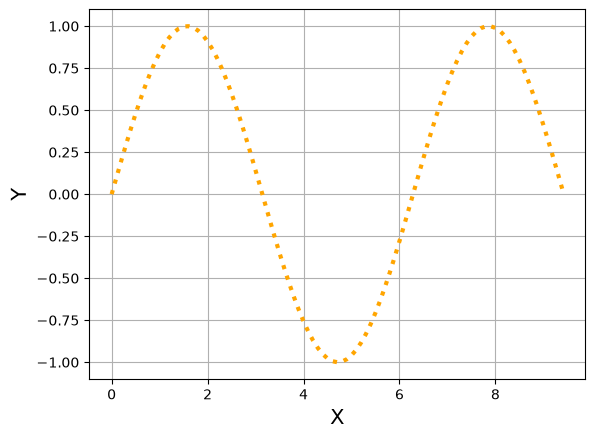

In [18]:
plt.grid(True)
plt.plot(x,y,":",lw=3,color='orange')
plt.ylabel("Y",size=15)
plt.xlabel("X",size=15)

The next graph plots a sine wave and a cosine wave on the same axes, and labels them so that they can be distinguished

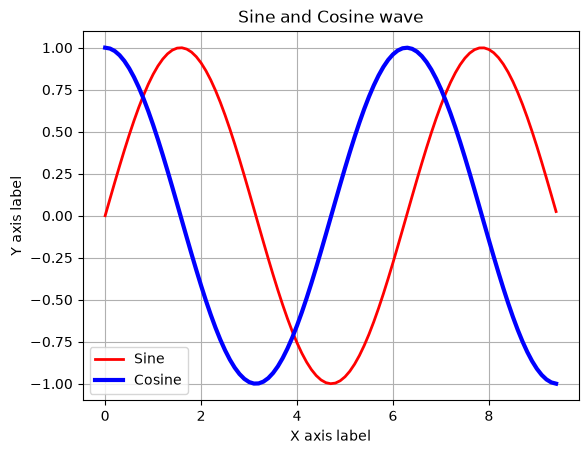

In [19]:
y_sin=np.sin(x)
y_cos=np.cos(x)

# plot the point using matplotlib
plt.plot(x,y_sin,lw=2,color='red')
plt.plot(x,y_cos,lw=3,color="blue")
plt.grid(True)
plt.title("Sine and Cosine wave")
plt.xlabel('X axis label')
plt.ylabel('Y axis label')
plt.legend(['Sine','Cosine'])

sometimes it is useful to have multiple plots in the same figure. This can be done as follows

Text(0.5, 1.0, 'Cosine')

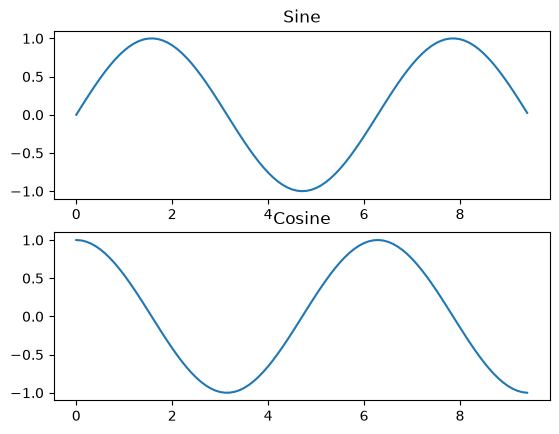

In [20]:
# set up a subplot grid that has height 2 and width 1,
# and set the first such subplot as active
plt.subplot(2,1,1)

# make the fist plot
plt.plot(x,y_sin)
plt.title('Sine')

# make the second subplot as activek, and make the second plot.
plt.subplot(2,1,2)
plt.plot(x,y_cos)
plt.title("Cosine")

### Seaborn

Seaborn is essentially a high-level interface to Matplotlib that is intended to make statistical data visualization easier.  Any plot that can be made in Seaborn can also be made in Matplotlib, but certain types of graphs are easier to make in Seaborn (and some others may be easier to make in Matplotlib).


#### Scatterplots

The following plot is a basic scatterplot.

In [35]:
# rading the dataset
df=pd.read_csv("Cartwheeldata.csv")
df.head()

,ID,Age,Gender,GenderGroup,Glasses,GlassesGroup,Height,Wingspan,CWDistance,Complete,CompleteGroup,Score
0,1,56,F,1,Y,1,62.0,61.0,79,Y,1,7
1,2,26,F,1,Y,1,62.0,60.0,70,Y,1,8
2,3,33,F,1,Y,1,66.0,64.0,85,Y,1,7
3,4,39,F,1,N,0,64.0,63.0,87,Y,1,10
4,5,27,M,2,N,0,73.0,75.0,72,N,0,4


<Axes: xlabel='Wingspan', ylabel='CWDistance'>

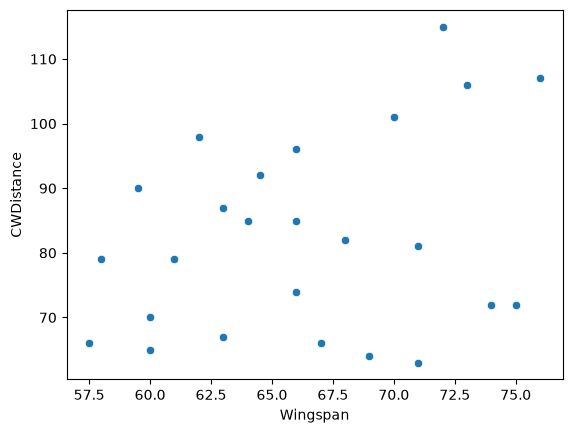

In [36]:
# create a scatterplot
sns.scatterplot(x="Wingspan",y="CWDistance",data=df)

Now we add more information to the scatterplot, by plotting females and males in different colors

<Axes: xlabel='Wingspan', ylabel='CWDistance'>

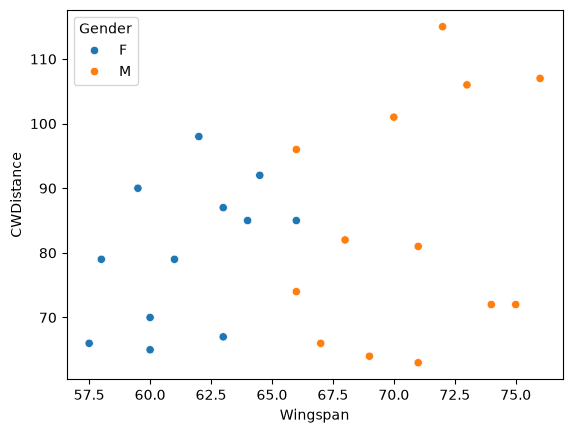

In [37]:
sns.scatterplot(x="Wingspan",y="CWDistance",hue="Gender",data=df)

A `Swarmplot` is a type of scatterplot for situations where one variable is categorical. Note that the categorical variable is `Jittered` to reduce overplotting

<Axes: xlabel='Gender', ylabel='CWDistance'>

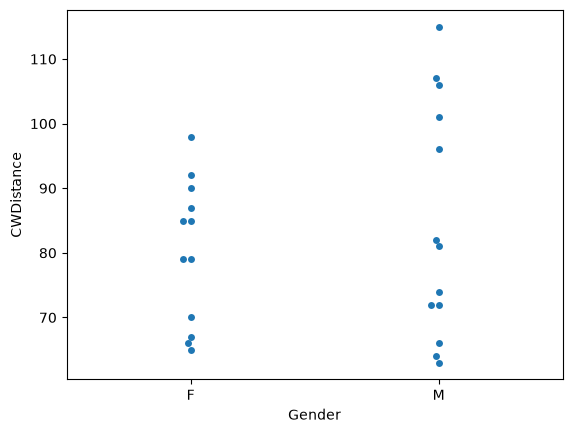

In [38]:
sns.swarmplot(x="Gender",y="CWDistance",data=df)

### Boxplots

A boxplot is one of the most useful ways to display several distributions side-by-side for comparision

<Axes: >

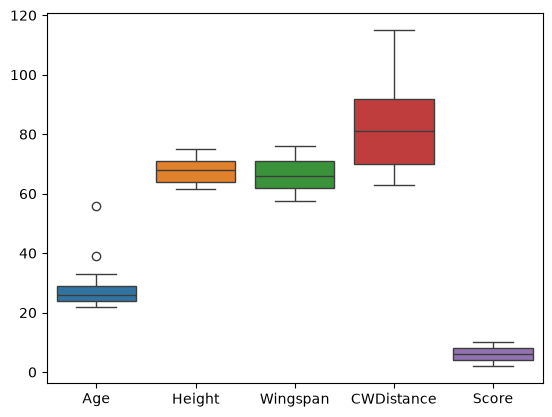

In [40]:
sns.boxplot(data=df.loc[:,['Age',"Height","Wingspan","CWDistance","Score"]])

<Axes: >

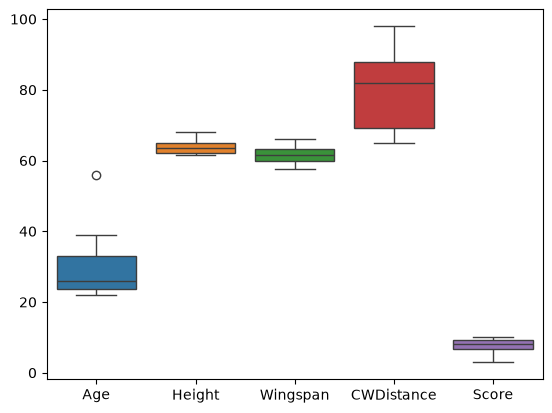

In [42]:
# A boxplot only for females
sns.boxplot(data=df.loc[df['Gender'] == 'F', ["Age", "Height", "Wingspan", "CWDistance", "Score"]])

<Axes: >

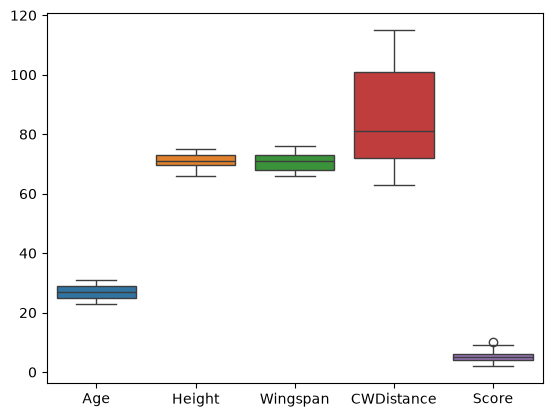

In [43]:
# A boxplot only for males
sns.boxplot(data=df.loc[df['Gender'] == 'M', ["Age", "Height", "Wingspan", "CWDistance", "Score"]])

### Histogram

A Histogram is a way to display the shape of a distibution

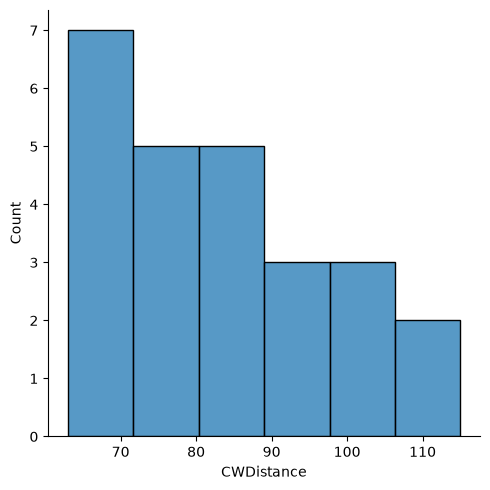

In [44]:
sns.displot(df.CWDistance)

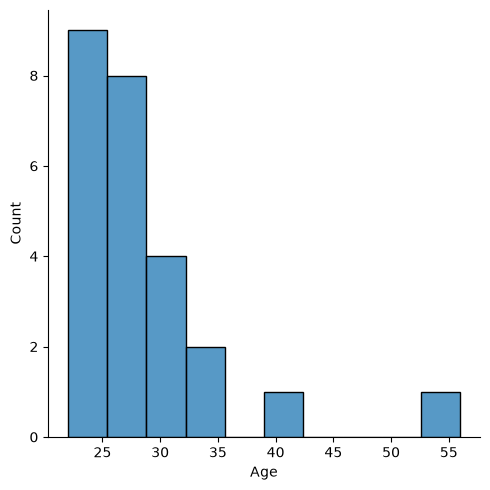

In [46]:
sns.displot(df.Age)

### Count plot

A count plot (bar plot) display frequencies

([0, 1], [Text(0, 0, 'F'), Text(1, 0, 'M')])

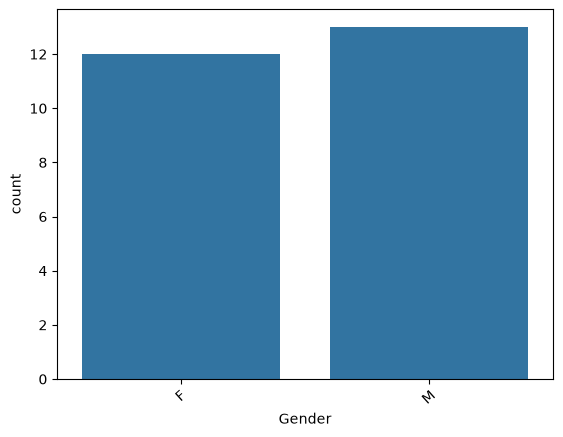

In [48]:
sns.countplot(x="Gender",data=df)
plt.xticks(rotation=42)